In the energy minimization process, the interface between two subunits are allowed to move and the rest is frozen. The free (nonfrozen) parts are then reconstructed as the new subunit (monomer). The input file is `/mnt/e/LargeSystem/npc/structure_correction/dimers/dilated_dimer.gro`

This file first determines what atoms to be frozen in the energy minimization process while gaurantee that the nonfrozen part covers more than, if not equal to, a intact subunit. In the second part, it reconstructs the structure of the subunit after the energy minimization by rotating the nonfrozen part of subunit 2 in place of the frozen part of subunit 1 (while resoving some merging issues). 

## Init

In [1]:
import sys
sys.path.append("/mnt/e/LargeSystem/npc/")

from init import *
import matplotlib.pyplot as plt

In [2]:
params={'font.family':'sans-serif',
        'font.sans-serif':'Arial',
        'font.weight':'normal', # or 'blod'
        'font.size': 16 # or large,small
        }
plt.rcParams.update(params)

## Determine the atoms to be frozen in the energy minimization

In [3]:
# Contacting chain indices
def contacts_inter(file):
    pair = []
    chain_max = 0
    with open(file, 'r') as fin:
        for line in fin:
            dat = line.strip().split()
            if int(dat[2]) > chain_max:
                chain_max = int(dat[2])
            if dat[0] != dat[2]:
                pair.append(tuple(map(int, (dat[0], dat[2]))))

    return pair, int(chain_max/2)

Read the contacts file generated by smog2 and get all the chain indices (`contacts`) for inter-chain interactions and the number of chains in a subunit (`chain_subunit`).

The contacts generated from smog 2 starts with 1 and did not restart counting for subunit 2. This means the chain index of subunit 2 starts with `chain_subunit + 1`

In [4]:
f_dilated_contacts = "/mnt/e/LargeSystem/npc/original_structure/dilated/original_SBM/openmm_del/dilated.contacts"
f_dilated_ndx = "/mnt/e/LargeSystem/npc/original_structure/dilated/original_SBM/openmm_del/dilated.ndx"

In [5]:
contacts, chain_subunit = contacts_inter(f_dilated_contacts)

Remove repeated contacts

In [6]:
contacts_set = np.array(list(set(contacts)))

The chain in the left is interacting with the chain in the right

In [7]:
contacts_set

array([[177, 181],
       [ 67,  68],
       [ 99, 100],
       ...,
       [ 85,  89],
       [195, 208],
       [  7,   8]])

In [8]:
chain_subunit

119

Contact Map

(0.5, 238.5)

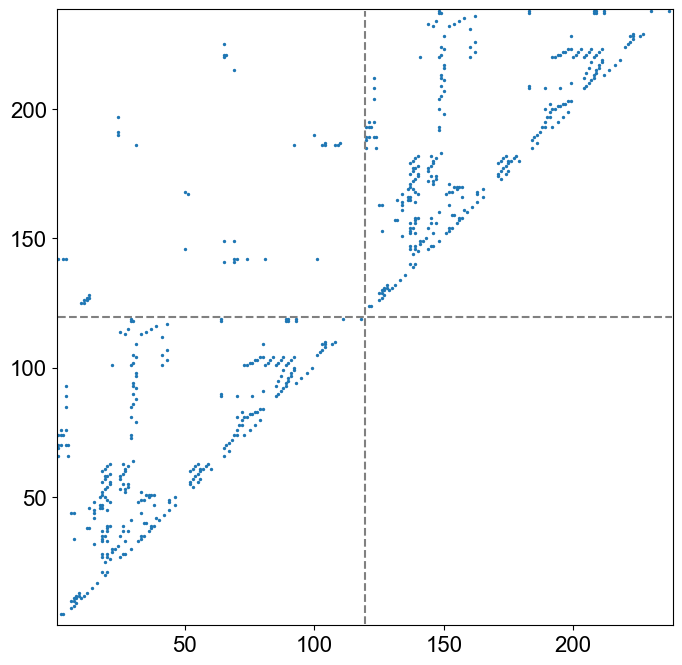

In [9]:
plt.figure(figsize=(8, 8))
plt.scatter(contacts_set[:, 0], contacts_set[:, 1], s = 2)
plt.hlines(chain_subunit+0.5, 1, chain_subunit*2, color = 'grey', linestyle = '--')
plt.vlines(chain_subunit+0.5, 1, chain_subunit*2, color = 'grey', linestyle = '--')
ax = plt.gca()
ax.set_aspect('equal')
plt.xlim(0.5, chain_subunit*2+0.5)
plt.ylim(0.5, chain_subunit*2+0.5)

Get the contacts between subunit 1 and subunit 2

In [9]:
# Inter-subunit contacts
inter = np.array(list(map(lambda x: x[0]<= chain_subunit and x[1] > chain_subunit, contacts_set)))

Get indices (`i1`) for all the chains in subunit 1 that interacts with subunit 2.

Also get the indices (`i2`) for all the chains in subunit 2 that interacts with subunit 1 but label them with the indices of their counterparts in subunit 1 (subtracting `chain_subunit`); this can also be seen as restarting counting the indices for subunit 2.

In [10]:
i1 = np.sort(list(set(contacts_set[inter][:, 0])))
i2 = np.sort(list(set(contacts_set[inter][:, 1]))) - chain_subunit

Any chain in `i1` of subunit 1 interact with at least one chain in `i2` of subunit 2. These chains will be free in the energy minimization process. The other chains will be assigned by hand to determine whether they will be free in subunit 1 or 2 (but it can not be both or neither). 

You may have noticed that chain 101 appears both in `i1` and `i2`, which means this chain interacts with both its previous and next subunit. 

My strategy is to leave them free in both subunits and deal with it after the minimization. Now think of it, it might be a better solution to divide this chain at this step and make sure all the atoms are frozen in either of the two subunits and free in the other.

In [11]:
print(i1)
print(i2)

[  1   3   4  10  11  12  13  24  31  50  51  65  66  69  70  74  81  92
 100 101 103 104 108 109 110]
[  6   7   8   9  22  23  27  30  48  49  67  68  71  72  78  96 101 102
 106]


In [12]:
def f(x1, x2):
    return list(range(x1, x2))

The chains that will be free (nonfrozen) in subunit 1

In [13]:
nonfreeze_1 = np.sort(f(1, 6) + f(10, 16) + f(24, 27) + f(31, 41) + f(50, 67) +\
                      f(69, 71) + f(74, 78) + f(81, 93) + f(100, 102) + f(103, 106) + f(108, 111))

The chains that will be free (nonfrozen) in subunit 2. If not for chain 101, it should have been the complement of `nonfreeze_1` counted consecutively (not restarting counting for subunit 2)

In [14]:
nonfreeze_2 = np.sort(list(set(range(1, chain_subunit+1)).difference(set(nonfreeze_1))) + [101]) + chain_subunit

Make sure that all the indices in `i1` are in `nonfreeze_1` and all the indices in `i2` are in `nonfreeze_2`

In [15]:
np.sum([1 - (i in nonfreeze_1) for i in i1])

0

In [16]:
np.sum([1 - (i+ chain_subunit in nonfreeze_2) for i in i2])

0

Indices of all the free (nonfrozen) chains

In [17]:
nonfreeze = np.concatenate((nonfreeze_1, nonfreeze_2))

Indices of all the frozen chains (the complement of the one above)

In [18]:
freeze = np.array(list(set(range(1, 2*chain_subunit+1)).difference(set(nonfreeze))))

Write the indices of all the **atoms** of the frozen indices into a `ndx` file, this file follows the rules in Gromacs and starts with 1 so you will need to substract it by 1 when using it in OpenMM

In [20]:
# Strating from 1 to match the ndx format
def write_ndx_txt(freeze, ndxfile, outfile):
    b_write = 0
    with open(outfile, 'w') as fout:
        with open(ndxfile, 'r') as fin:
            for line in fin:
                dat = line.strip().split()
                if len(dat) > 0 and dat[0] == '[':
                    if int(dat[1]) in freeze:
                        b_write = 1
                    else:
                        b_write = 0
                if b_write == 1:
                    try:
                        int(dat[0])
                        fout.write(dat[0]+"\n")
                    except:
                        continue

Read the atom indices for selected chains from the `ndx` file generated by smog 2

In [19]:
# Get the index of chain ids, starting from 0 to match mdtraj
def get_index(freeze, ndxfile):
    ndx = []
    b_write = 0
    with open(ndxfile, 'r') as fin:
        for line in fin:
            dat = line.strip().split()
            if len(dat) > 0 and dat[0] == '[':
                if int(dat[1]) in freeze:
                    b_write = 1
                else:
                    b_write = 0
            if b_write == 1:
                try:
                    ndx.append(int(dat[0]))
                except:
                    continue
    return np.array(ndx) - 1 # starting from 0

In [36]:
write_ndx_txt(freeze, f_dilated_ndx, 'freeze_dilated.ndx')

## Load and rotate pdb

In [20]:
freeze

array([  6,   7,   8,   9,  16,  17,  18,  19,  20,  21,  22,  23,  27,
        28,  29,  30,  41,  42,  43,  44,  45,  46,  47,  48,  49,  67,
        68,  71,  72,  73,  78,  79,  80,  93,  94,  95,  96,  97,  98,
        99, 102, 106, 107, 111, 112, 113, 114, 115, 116, 117, 118, 119,
       120, 121, 122, 123, 124, 129, 130, 131, 132, 133, 134, 143, 144,
       145, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 169, 170,
       171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183,
       184, 185, 188, 189, 193, 194, 195, 196, 200, 201, 202, 203, 204,
       205, 206, 207, 208, 209, 210, 211, 219, 222, 223, 224, 227, 228,
       229])

In [21]:
import mdtraj as md
# import copy

Load the final frame from the energy minimization (file not uploaded)

In [22]:
em = md.load("steps/emin.gro")

This is only loaded because I need to divide the chain 101 and I want to keep the residues intact. I could not think of a better way to store the residue information so I used mdtraj. This should be avoided in general because mdtraj organized everything and provide you with a lot of information you won't need. This is time-consuming. I have a simpler PDB reader below and it is much faster.

In [23]:
# Subunit 1 is read as template
sub1 = md.load("/mnt/e/LargeSystem/npc/original_structure/dilated/adjust_1.pdb")

Rotation center copied from `axis.ipynb` and converted into nm.  

In [24]:
c = C_DILATED_A/10
# Rotate subunit 2 inplace of subunit 1
# Rotate clockwise around the z-axis by 45 degrees, right multiplied
A = Rotate_Z(theta = -np.pi/4)

Number of atoms in a subunit

In [25]:
N_atoms_subunit = em.n_atoms//2
print(N_atoms_subunit, em.n_atoms)

617133 1234266


### check chain 101

#### Plot

Rotate subunit 2 to supopose it with subunit 1

In [26]:
sub2_rot = (em.xyz[0, N_atoms_subunit:] - c)@A + c

Atom distances between the two subunits

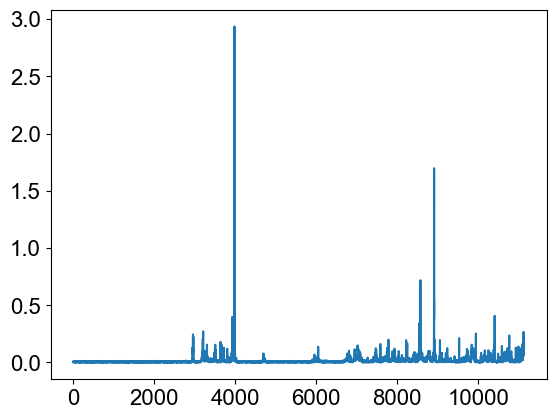

In [27]:
plt.plot(np.sqrt(((sub2_rot[get_index([101], f_dilated_ndx)] - em.xyz[0, get_index([101], f_dilated_ndx)])**2).sum(axis = 1))*10)

Indices between 3000 to 5000 from the figure above

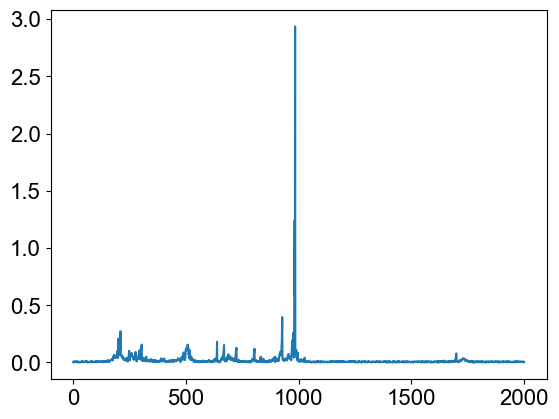

In [28]:
plt.plot(np.sqrt(((sub2_rot[get_index([101], f_dilated_ndx)] - em.xyz[0, get_index([101], f_dilated_ndx)])**2).sum(axis = 1))[3000:5000]*10)

In [29]:
np.argmax(((sub2_rot[get_index([101], f_dilated_ndx)] - em.xyz[0, get_index([101], f_dilated_ndx)])**2).sum(axis = 1))

3984

#### Decide the construction of chain 101

Again, it might be better to do this before energy minimization

In [30]:
chain101_index = get_index([101], f_dilated_ndx)
# chain101_sub2_index = chain101_index + N_atoms_subunit 

Get the atom *serial* in chain 101 that interacts with its neighbor subunit from the `contacts` file generated by smog 2.

Notice that we are reading atom *serial* here which restarts from 1 for every chain

In [31]:
# Contacting atom indices for chain 101, mdtraj style
def contacts_101(file):
    pair = [[],[]]
    with open(file, 'r') as fin:
        for line in fin:
            dat = line.strip().split()
            if int(dat[0]) == 101 and int(dat[2]) > chain_subunit:
                pair[0].append(int(dat[1]) - 1)
            if int(dat[2]) == 101 + chain_subunit and int(dat[0]) <= chain_subunit:
                pair[1].append(int(dat[3]) - 1)
            # make sure that the two "chain 101" are not interacting
            if int(dat[0]) == 101 and int(dat[2]) == 101 + chain_subunit:
                print("ERROR")
    return list(map(set, pair))

In [32]:
index_101 = contacts_101(f_dilated_contacts)

The atoms in the chain 101 of subunit 1 that need to be kept in the new subunit, or in the language of selection before energy minimization, the atoms that are free (nonfrozen) in subunit 1

In [33]:
np.sort(list(index_101[0]))

array([11078, 11080, 11088, 11090, 11093, 11120, 11121, 11122, 11130])

Same but for subunit 2

In [34]:
np.sort(list(index_101[1]))

array([2949, 2952, 2954, 2959, 2966, 2967, 3196, 3197, 3200, 3207, 3209,
       3210, 3482, 3485, 3488, 3491, 3494, 3496, 3507, 3508, 3509, 3510,
       3511, 3514, 3747, 3754, 3887, 3918, 3922, 3924, 3926, 3954, 3955,
       3960, 3961, 3981, 3983, 3994, 3996])

There is an obvious separation between the two subgroups. The idea is to get the residue index for serial 3996, and everything in chain 101 before this residue will be from subunit 2 and those after will be from subunit 1

This is the reason we loaded the subunit 1 pdb with mdtraj, to get the residue information. `chain101_index_sub2_end` is the *index* to stop

In [35]:
chain101_index_sub2_end = sub1.top.chain(100).atom(3996).residue.atom(-1).index
chain101_index_sub2_end

540335

In [36]:
chain101_index

array([536339, 536340, 536341, ..., 547468, 547469, 547470])

This group (from subunit 2) will be rotated to construct part of the chain 101 in the new subunit

In [37]:
chain101_index_sub2_rotate = np.arange(chain101_index[0], chain101_index_sub2_end+1) + N_atoms_subunit

In [38]:
chain101_index_sub2_rotate

array([1153472, 1153473, 1153474, ..., 1157466, 1157467, 1157468])

### Prepare Rotation

In [39]:
nonfreeze_2

array([125, 126, 127, 128, 135, 136, 137, 138, 139, 140, 141, 142, 146,
       147, 148, 149, 160, 161, 162, 163, 164, 165, 166, 167, 168, 186,
       187, 190, 191, 192, 197, 198, 199, 212, 213, 214, 215, 216, 217,
       218, 220, 221, 225, 226, 230, 231, 232, 233, 234, 235, 236, 237,
       238])

Remove chain 101 of subunit 2 for now since we have already taken care of it, will add them back later

In [40]:
nonfreeze_2_no101 = np.sort(list(set(range(1, chain_subunit+1)).difference(set(nonfreeze_1)))) + chain_subunit
nonfreeze_2_no101

array([125, 126, 127, 128, 135, 136, 137, 138, 139, 140, 141, 142, 146,
       147, 148, 149, 160, 161, 162, 163, 164, 165, 166, 167, 168, 186,
       187, 190, 191, 192, 197, 198, 199, 212, 213, 214, 215, 216, 217,
       218, 221, 225, 226, 230, 231, 232, 233, 234, 235, 236, 237, 238])

Get the indices of the atoms that will be rotated to construct the new subunit, also adding the chain 101 part we missed

In [41]:
rotate_2_index = np.hstack([get_index(nonfreeze_2_no101, f_dilated_ndx), chain101_index_sub2_rotate])

In [42]:
rotate_2_index_sorted = np.sort(rotate_2_index)

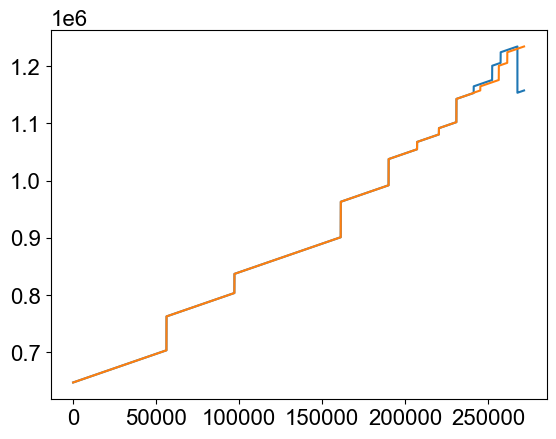

In [43]:
plt.plot(rotate_2_index)
plt.plot(rotate_2_index_sorted)

### Rotation

`rotate_2_index_sorted` stores the indices in subunit 2 that will be rotated

`index2` stores the indices of its counterpart in subunit 1 (that will be removed) and also in the new subunit we are building

In [44]:
# Start with 0 to match np.array, coordinates with this index are replcaed with rotated coordinates from subunit 2
index2 = rotate_2_index_sorted - N_atoms_subunit

In [45]:
index2

array([ 30425,  30426,  30427, ..., 617130, 617131, 617132])

`index1` stores the indices in subunit 1 that will be kept, which is the complement of `index2`. It can also be constructed from `nonfreeze_1` by removing some indices in chain 101 but why bother...

In [46]:
index1 = np.sort(list(set(range(N_atoms_subunit)).difference(set(index2))))

In [47]:
index1

array([     0,      1,      2, ..., 606992, 606993, 606994])

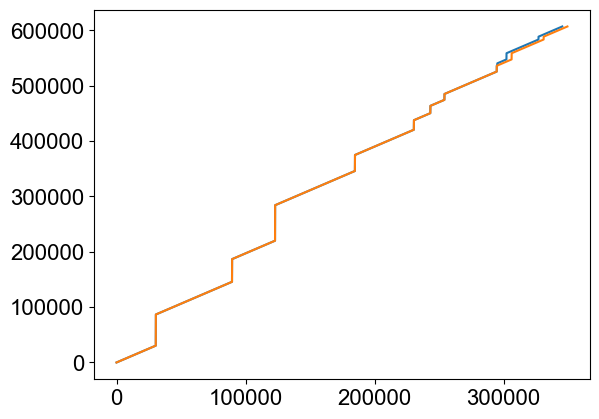

In [48]:
plt.plot(index1)    
plt.plot(get_index(nonfreeze_1, f_dilated_ndx))

In [49]:
rotate_2_index_sorted.shape

(271578,)

In [50]:
em.xyz[0][rotate_2_index_sorted].shape

(271578, 3)

Get the atom coordinates that will be rotated and then rotate them

In [51]:
rotate_2_xyz = em.xyz[0][rotate_2_index_sorted]
rotate_2_xyz_afterrotation = (rotate_2_xyz - c)@A + c

#### Get coordinates

Construct an empty array for the new subunit. This `sub1_xyz` stores the coordinates for our new subunit

In [52]:
sub1_xyz = np.zeros((N_atoms_subunit, 3))

Combine the coordinates from subunit 1 and 2 for the new subunit

In [53]:
sub1_xyz[index1] = em.xyz[0][index1]
sub1_xyz[index2] = rotate_2_xyz_afterrotation

#### Test

In [54]:
rotate_2_xyz_afterrotation[0]

array([ 48.327395  , 151.18314857,  95.32499695])

In [55]:
sub1_xyz[index2[0]]

array([ 48.327395  , 151.18314857,  95.32499695])

In [56]:
sub1.xyz[0][index2][0]

array([ 48.2294, 151.1742,  95.3053], dtype=float32)

In [57]:
sub2_rotated = (em.xyz[0, N_atoms_subunit:] - c)@A + c

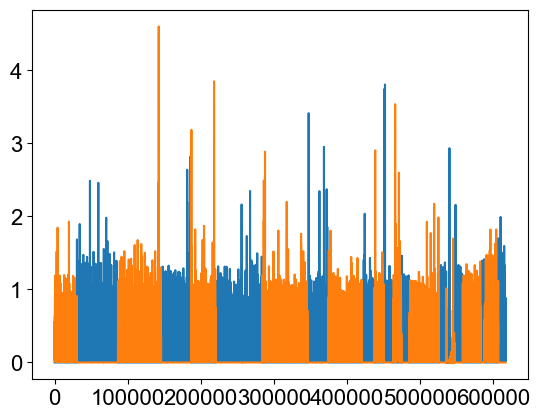

In [58]:
plt.plot(np.sqrt(((em.xyz[0][:N_atoms_subunit] - sub1_xyz)**2).sum(axis = 1))*10)
plt.plot(np.sqrt(((sub2_rotated - sub1_xyz)**2).sum(axis = 1))*10)

### Write the pdb file

In [59]:
# Convert from nm to Angstrom
sub1_xyz_A = sub1_xyz*10

In [60]:
t = write_subunit("/mnt/e/LargeSystem/npc/original_structure/dilated/adjust_1.pdb", "reconstruct/em_sub1.pdb", sub1_xyz_A)

In [61]:
t = write_subunits("reconstruct/em_sub1.pdb", "reconstruct/em_dimer.pdb", C_DILATED_A, 2)

In [62]:
t = write_subunits("reconstruct/em_sub1.pdb", "reconstruct/dilated_reconstruct.pdb", C_DILATED_A, 8)